In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [27]:
#Loading the dataset

data = pd.read_csv('processed_cars_data (3).csv')
display(data.head())

,Cars Prices,HorsePower_x_CC,HorsePower_x_Speed,HorsePower_x_Torque,Company_Clean_Acura,Company_Clean_BMW,Company_Clean_Chevrolet,Company_Clean_Ford,Company_Clean_GMC,Company_Clean_HYUNDAI,...,Company_Clean_Other,Company_Clean_Peugeot,Company_Clean_Porsche,Company_Clean_TOYOTA,Company_Clean_Tata Motors,Company_Clean_Volkswagen,Fuel Types_Clean_Electric,Fuel Types_Clean_Hybrid,Fuel Types_Clean_Hydrogen,Fuel Types_Clean_Petrol
0,1100000.0,0.127280,0.318009,0.112257,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
1,460000.0,0.123400,0.119165,0.072856,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,13500.0,0.002102,0.005714,0.000613,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,161000.0,0.081881,0.134033,0.081946,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,253290.0,0.102056,0.180451,0.047071,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [28]:
# Separate features and target
X = data.drop('Cars Prices', axis=1)
y = data['Cars Prices']

# Log-transform the target to stabilize large price variations
y = np.log1p(y)   # log(1 + price) prevents log(0) errors

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [29]:
#Splitting the dataset

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [30]:
#Model Training
svr = SVR(kernel='rbf', C=100, epsilon=0.1, gamma='scale')
svr.fit(X_train, y_train)


SVR(C=100)

In [31]:
#Model Predicting
# Predict on test data (log scale)
y_pred_log = svr.predict(X_test)

# Convert predictions back to real prices
y_pred = np.expm1(y_pred_log)
y_test_exp = np.expm1(y_test)


In [32]:
#Model Evaluation
mse = mean_squared_error(y_test_exp, y_pred)
r2 = r2_score(y_test_exp, y_pred)

print("Improved MSE:", mse)
print("Improved R²:", r2)


Improved MSE: 139450519517.62704
Improved R²: 0.7633058755923987


In [33]:
#Parameter Tuning

param_grid = {
    'C': [1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='r2', verbose=1)
grid_search.fit(X_train, y_train)

best_svr = grid_search.best_estimator_

y_pred_log = best_svr.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_exp = np.expm1(y_test)

mse = mean_squared_error(y_test_exp, y_pred)
r2 = r2_score(y_test_exp, y_pred)

print("Tuned Parameters:", grid_search.best_params_)
print("Improved MSE:", mse)
print("Improved R²:", r2)



Fitting 5 folds for each of 18 candidates, totalling 90 fits
Tuned Parameters: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Improved MSE: 147400748424.76044
Improved R²: 0.7498116808305351


In [34]:
#Re-evaluation after tuning
y_pred_best = best_svr.predict(X_test)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("Optimized MSE:", mse_best)
print("Optimized R²:", r2_best)


Optimized MSE: 0.09535319585416484
Optimized R²: 0.9206817579183804


In [41]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Predict (log scale)
y_pred_log = best_svr.predict(X_test)

# Convert back to original price scale
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

# Metrics
mse = mean_squared_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)
print("MSE:", mse)
print("R2:", r2)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

# Show first 10 predictions vs actual
for i in range(10):
    print(f"Pred: {y_pred[i]:.2f}, Actual: {y_test_orig.values[i]:.2f}, Error: {y_pred[i]-y_test_orig.values[i]:.2f}")


MSE: 147400748424.76044
R2: 0.7498116808305351
RMSE: 383928.0511043188
Pred: 28021.51, Actual: 15400.00, Error: 12621.51
Pred: 15375.41, Actual: 16500.00, Error: -1124.59
Pred: 75897.77, Actual: 109000.00, Error: -33102.23
Pred: 414462.66, Actual: 390000.00, Error: 24462.66
Pred: 81041.33, Actual: 500000.00, Error: -418958.67
Pred: 80041.65, Actual: 55000.00, Error: 25041.65
Pred: 303306.55, Actual: 208000.00, Error: 95306.55
Pred: 38487.46, Actual: 50000.00, Error: -11512.54
Pred: 38052.37, Actual: 42500.00, Error: -4447.63
Pred: 130683.23, Actual: 129900.00, Error: 783.23


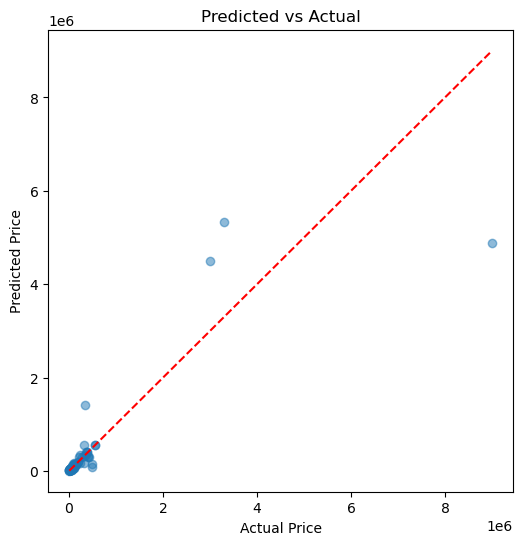

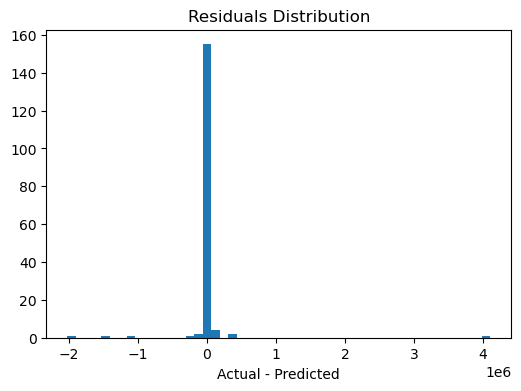

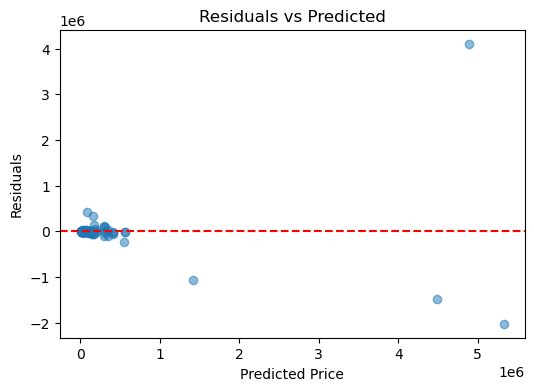

In [42]:
import matplotlib.pyplot as plt

# Pred vs actual scatter
plt.figure(figsize=(6,6))
plt.scatter(y_test_orig, y_pred, alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual')
plt.show()

# Residuals histogram
residuals = y_test_orig - y_pred
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)
plt.title('Residuals Distribution')
plt.xlabel('Actual - Predicted')
plt.show()

# Residuals vs predicted (look for patterns)
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()


In [43]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Use neg_mean_squared_error and r2
mse_scores = -cross_val_score(best_svr, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
r2_scores = cross_val_score(best_svr, X_train, y_train, cv=kf, scoring='r2')

print("CV MSE (mean ± std):", mse_scores.mean(), mse_scores.std())
print("CV R2 (mean ± std):", r2_scores.mean(), r2_scores.std())


CV MSE (mean ± std): 0.1220408973986502 0.04622541151740935
CV R2 (mean ± std): 0.8953366808751868 0.03322133819418354


In [44]:
# example sample
sample = X_test[0:1]  
pred_log = best_svr.predict(sample)
pred_price = np.expm1(pred_log)
print("Predicted price:", pred_price[0])


Predicted price: 28021.508614881943


In [45]:
#Identifying the importance of features used for the predictions

from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

# Use test data and log-transformed target
result = permutation_importance(best_svr, X_test, y_test, n_repeats=10, random_state=42)

# Create DataFrame for easy viewing
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print(importance_df)


                      Feature  Importance
0             HorsePower_x_CC    0.495578
1          HorsePower_x_Speed    0.358777
2         HorsePower_x_Torque    0.126683
5     Company_Clean_Chevrolet    0.030714
16      Company_Clean_Porsche    0.030127
23    Fuel Types_Clean_Petrol    0.020762
14        Company_Clean_Other    0.017546
6          Company_Clean_Ford    0.016940
3         Company_Clean_Acura    0.014152
10  Company_Clean_LAMBORGHINI    0.012554
17       Company_Clean_TOYOTA    0.011384
8       Company_Clean_HYUNDAI    0.011367
7           Company_Clean_GMC    0.011178
18  Company_Clean_Tata Motors    0.010638
11        Company_Clean_Mazda    0.008436
9           Company_Clean_Kia    0.007576
19   Company_Clean_Volkswagen    0.007241
12   Company_Clean_Mitsubishi    0.007208
4           Company_Clean_BMW    0.005518
21    Fuel Types_Clean_Hybrid    0.005416
15      Company_Clean_Peugeot    0.004082
22  Fuel Types_Clean_Hydrogen    0.002140
13       Company_Clean_Nissan    0

In [46]:
import joblib

joblib.dump(best_svr, 'svr_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

# later / in another script
svr_loaded = joblib.load('svr_model.joblib')
scaler_loaded = joblib.load('scaler.joblib')

# quick test
x0 = X_test[0:3]
print(np.expm1(svr_loaded.predict(x0)))


[28021.50861488 15375.40848272 75897.77218393]
